# Obtén datos de la API de la Nasa

![imagen](img/nasa.jpg)

Te tendrás que [registrar](https://api.nasa.gov/) y consultar la documentación.

### Importaciones necesarias.

In [2]:
pip install requests


   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
import json

## Ejercicio 1: Tienes que descargarte la foto de la nasa del día de tu cumpleaños del año pasado, imprimir el título y la descripción.

Foto descargada como foto_nasa.jpg:


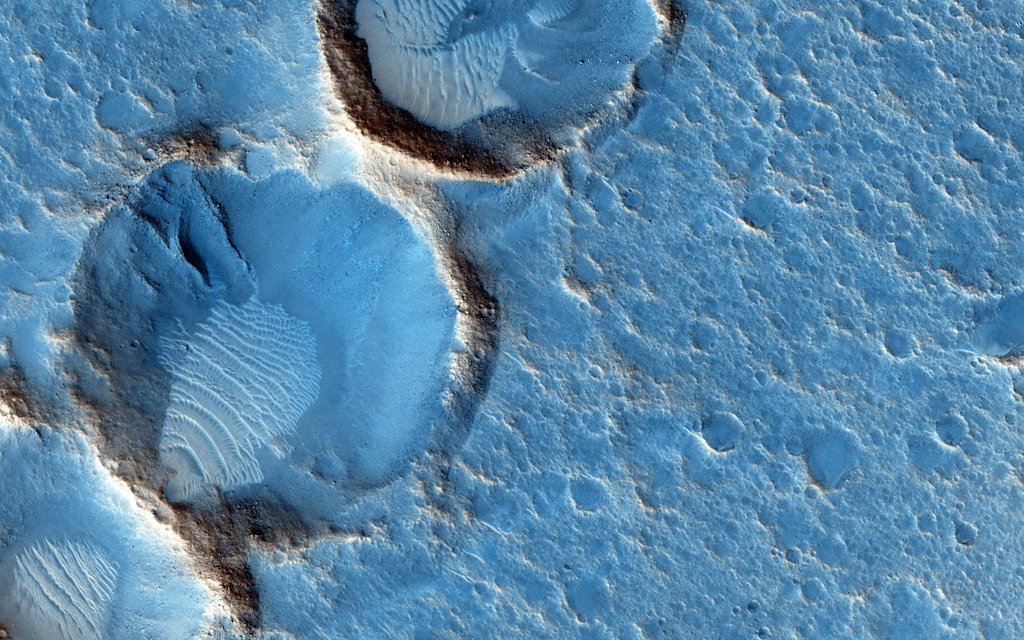

In [11]:
url = "https://api.nasa.gov/planetary/apod" # esta es la dirección web del endpoint que necesitamos

# aquí debajo están los parámetros que hay que introducir: API key y fecha

params = {
    "api_key": "YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR",
    "date": "2025-05-17"
}

url_imagen = data["url"] # obtenemos la url de la imagen
imagen = requests.get(url_imagen) # obtenemos la imagen

with open("foto_nasa.jpg", "wb") as foto: # creamos un archivo con el nombre foto_nasa
    foto.write(imagen.content) # incluimos los datos de la imagen en ese archivo

print("Foto descargada como foto_nasa.jpg:") 

from IPython.display import Image # con estas dos líneas mostramos la imagen directamente en el jupyter notebook
Image(filename="foto_nasa.jpg")

In [ ]:
response = requests.get(url, params=params) # pedimos datos a la NASA a través de los parámetros de la API y obtenemos el objeto response
diccionario = response.json() # convertimos el json que nos da la NASA en un diccionario

print("Título:", diccionario["title"]) #obtenemos el campo title del diccionario
print("Descripción:", diccionario["explanation"]) # obtenemos el campo explanation del diccionario

Título: Ares 3 Landing Site: The Martian Revisited
Descripción: This close-up from the Mars Reconnaissance Orbiter's HiRISE camera shows weathered craters and windblown deposits in southern Acidalia Planitia. A striking shade of blue in standard HiRISE image colors, to the human eye the area would probably look grey or a little reddish. But human eyes have not gazed across this terrain, unless you count the eyes of NASA astronauts in the sci-fi novel, "The Martian," by Andy Weir. The novel chronicles the adventures of Mark Watney, an astronaut stranded at the fictional Mars mission Ares 3 landing site, corresponding to the coordinates of this cropped HiRISE frame. For scale, Watney's 6-meter-diameter habitat at the site would be about 1/10th the diameter of the large crater. Of course, the Ares 3 landing coordinates are only about 800 kilometers north of the (real life) Carl Sagan Memorial Station, the 1997 Pathfinder landing site.


## Ejercicio 2: Extraer todos los asteroides que han pasado cerca de la tierra esta última semana. Tenéis que mostrar los datos en un DataFrame, y guardarlos en un CSV.

In [14]:
# importo las librerías
import requests
import pandas as pd
import json

Primero hago la extracción de la API:

In [ ]:
url = "https://api.nasa.gov/neo/rest/v1/feed" # esta es la dirección web del endpoint que necesitamos

# incluimos los parámetros necesarios

params = {
    "api_key": "YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR",
    "start_date": "2026-05-04",
    "end_date": "2026-05-08"
}

response = requests.get(url, params=params) # pedimos datos a la NASA a través de los parámetros de la API y obtenemos el objeto response

datos = response.json() # convertimos el json que nos da la NASA en un diccionario

print(json.dumps(datos, indent=4)) # miro el json para ver que datos quiero incluir en el dataframe


{
    "links": {
        "next": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2026-05-08&end_date=2026-05-12&detailed=false&api_key=YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR",
        "previous": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2026-04-30&end_date=2026-05-04&detailed=false&api_key=YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR",
        "self": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2026-05-04&end_date=2026-05-08&detailed=false&api_key=YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR"
    },
    "element_count": 19,
    "near_earth_objects": {
        "2026-05-08": [
            {
                "links": {
                    "self": "http://api.nasa.gov/neo/rest/v1/neo/3653390?api_key=YufD5SZ1NI8rkoxKKwedalfesDhXX6LcDZLDiDtR"
                },
                "id": "3653390",
                "neo_reference_id": "3653390",
                "name": "(2013 VL)",
                "nasa_jpl_url": "https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3653390",
            

Ahora obtengo los asteroides a través de una lista con los valores del diccionario "near_earth_objects":

In [30]:
asteroides = [] # creo la lista

for lista in datos["near_earth_objects"].values(): # itero entre los valores de los elementos de la lista
    asteroides.extend(lista)

df_asteroides = pd.json_normalize(asteroides) # creo el dataframe a partir de la lista, pero con el método json_normalize ya que hay diccionarios anidados

print(f"El dataframe df_asteroides sería:")
print()
df_asteroides

El dataframe df_asteroides sería:



,id,neo_reference_id,name,nasa_jpl_url,absolute_magnitude_h,is_potentially_hazardous_asteroid,close_approach_data,is_sentry_object,links.self,estimated_diameter.kilometers.estimated_diameter_min,estimated_diameter.kilometers.estimated_diameter_max,estimated_diameter.meters.estimated_diameter_min,estimated_diameter.meters.estimated_diameter_max,estimated_diameter.miles.estimated_diameter_min,estimated_diameter.miles.estimated_diameter_max,estimated_diameter.feet.estimated_diameter_min,estimated_diameter.feet.estimated_diameter_max,sentry_data
0,3653390,3653390,(2013 VL),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,27.70,False,"[{'close_approach_date': '2026-05-08', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3653390?ap...,0.007666,0.017141,7.665756,17.141151,0.004763,0.010651,25.150118,56.237374,NaN
1,3719730,3719730,(2015 KB57),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,22.30,False,"[{'close_approach_date': '2026-05-08', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3719730?ap...,0.092163,0.206082,92.162655,206.081961,0.057267,0.128053,302.370925,676.121942,NaN
2,3143095,3143095,(2002 VU114),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,22.80,False,"[{'close_approach_date': '2026-05-07', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3143095?ap...,0.073207,0.163697,73.207399,163.696720,0.045489,0.101716,240.181763,537.062748,NaN
3,3374391,3374391,(2007 HW4),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,23.60,False,"[{'close_approach_date': '2026-05-07', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3374391?ap...,0.050647,0.113250,50.647146,113.250461,0.031471,0.070371,166.165182,371.556643,NaN
4,3799712,3799712,(2018 DT),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,27.10,False,"[{'close_approach_date': '2026-05-07', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3799712?ap...,0.010105,0.022596,10.105434,22.596438,0.006279,0.014041,33.154313,74.135297,NaN
5,3461231,3461231,(2009 KR4),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,25.00,False,"[{'close_approach_date': '2026-05-06', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3461231?ap...,0.026580,0.059435,26.580000,59.434687,0.016516,0.036931,87.204727,194.995698,NaN
6,3763274,3763274,(2016 VB1),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,28.57,False,"[{'close_approach_date': '2026-05-06', 'close_...",True,http://api.nasa.gov/neo/rest/v1/neo/3763274?ap...,0.005135,0.011483,5.135172,11.482593,0.003191,0.007135,16.847677,37.672551,http://api.nasa.gov/neo/rest/v1/neo/sentry/376...
7,3843898,3843898,(2019 SX),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,29.60,False,"[{'close_approach_date': '2026-05-06', 'close_...",True,http://api.nasa.gov/neo/rest/v1/neo/3843898?ap...,0.003196,0.007146,3.195619,7.145621,0.001986,0.004440,10.484314,23.443639,http://api.nasa.gov/neo/rest/v1/neo/sentry/384...
8,3532401,3532401,(2010 MS1),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,21.89,False,"[{'close_approach_date': '2026-05-05', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3532401?ap...,0.111315,0.248909,111.315330,248.908644,0.069168,0.154665,365.207786,816.629435,NaN
9,3654644,3654644,(2013 XS23),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,26.30,False,"[{'close_approach_date': '2026-05-05', 'close_...",False,http://api.nasa.gov/neo/rest/v1/neo/3654644?ap...,0.014607,0.032662,14.606796,32.661790,0.009076,0.020295,47.922562,107.158106,NaN


In [47]:
df_asteroides.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 18 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id                                                    19 non-null     str    
 1   neo_reference_id                                      19 non-null     str    
 2   name                                                  19 non-null     str    
 3   nasa_jpl_url                                          19 non-null     str    
 4   absolute_magnitude_h                                  19 non-null     float64
 5   is_potentially_hazardous_asteroid                     19 non-null     bool   
 6   close_approach_data                                   19 non-null     object 
 7   is_sentry_object                                      19 non-null     bool   
 8   links.self                                            19 non-null     str

Por último, convierto el dataframe a un csv, que se guarda en la misma carpeta que este ejercicio:

In [33]:
csv_asteroides = df_asteroides.to_csv("asteroides.csv", index=False)

## Ejercicio 3. Descargar todos los datos de Sentry Data Service. Es un conjunto de objetos con posibilidad de impactar en la tierra en los próximos 100 años. Guarda todos los posibles en un csv, y muéstrame el que tiene más posibilidades de impactar contra la tierra.

In [ ]:
url = "https://ssd-api.jpl.nasa.gov/sentry.api" # esta es la dirección web del endpoint que necesitamos, obtenida de otra web: "https://ssd-api.jpl.nasa.gov/doc/sentry.html"

response = requests.get(url) # pedimos datos a la NASA a través de los parámetros de la API y obtenemos el objeto response

datos_sentry = response.json() # convertimos el json que nos da la NASA en un diccionario

print(json.dumps(datos_sentry, indent=4)) # muestro el json para ver qué incluye


{
    "data": [
        {
            "last_obs": "1979-12-15",
            "v_inf": "23.7606234552547",
            "ip": "8.515158e-07",
            "h": "18.54",
            "range": "2056-2113",
            "n_imp": 4,
            "last_obs_jd": "2444222.5",
            "fullname": "(1979 XB)",
            "ps_max": "-2.99",
            "ts_max": "0",
            "diameter": "0.66",
            "ps_cum": "-2.69",
            "id": "bJ79X00B",
            "des": "1979 XB"
        },
        {
            "ip": "0.0001203297828",
            "v_inf": "15.5694051293592",
            "last_obs": "2022-05-23",
            "range": "2060-2122",
            "h": "28.45",
            "n_imp": 33,
            "ts_max": "0",
            "ps_max": "-5.79",
            "fullname": "(2022 KK2)",
            "last_obs_jd": "2459722.5",
            "diameter": "0.0069",
            "des": "2022 KK2",
            "id": "bK22K02K",
            "ps_cum": "-5.59"
        },
        {
            "ps_

Ahora tengo que convertir el diccionario en un dataframe:

In [48]:
df_sentry = pd.json_normalize(datos_sentry["data"])
df_sentry.info()


<class 'pandas.DataFrame'>
RangeIndex: 2138 entries, 0 to 2137
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   last_obs     2138 non-null   str  
 1   v_inf        2138 non-null   str  
 2   ip           2138 non-null   str  
 3   h            2138 non-null   str  
 4   range        2138 non-null   str  
 5   n_imp        2138 non-null   int64
 6   last_obs_jd  2138 non-null   str  
 7   fullname     2138 non-null   str  
 8   ps_max       2138 non-null   str  
 9   ts_max       2136 non-null   str  
 10  diameter     2138 non-null   str  
 11  ps_cum       2138 non-null   str  
 12  id           2138 non-null   str  
 13  des          2138 non-null   str  
dtypes: int64(1), str(13)
memory usage: 234.0 KB


In [ ]:
df_sentry.to_csv("sentry.csv", index=False) # creo el archivo csv y lo guardo en la misma carpeta que este ejercicio

Se que el valor que tengo que buscar es el máximo de la columna ps_cum, que es la que mide el riesgo de impacto. Cuanto más cercano a 0, más probabilidad. El problema es que esa columna es un string, con lo que primero tengo que transformarla a float. Después ya obtengo el índice máximo y lo imprimo.

In [ ]:
ps_cum_float = df_sentry["ps_cum"].astype(float)

maximo = ps_cum_float.idxmax() # obtengo el índice máximo de la columna

df_sentry.loc[[maximo]] # muestro ese índice máximo

,last_obs,v_inf,ip,h,range,n_imp,last_obs_jd,fullname,ps_max,ts_max,diameter,ps_cum,id,des
1525,2025-04-28,14.10,3.770e-04,17.94,2880-2880,1,2460793.5,29075 (1950 DA),-0.93,NaN,1.3,-0.93,a0029075,29075


Compruebo, ordenando de mayor a menor, que el objeto 1525 es el que tiene el valor máximo en la columna ps_cum

In [58]:
ps_cum_float.sort_values(ascending=False)

1525    -0.93
1362    -1.40
600     -2.38
0       -2.69
2       -2.77
        ...  
2022   -11.46
242    -11.78
1446   -11.81
1190   -11.82
342    -12.14
Name: ps_cum, Length: 2138, dtype: float64